In [1]:
# CNN - CIFAR-10 Image Classification
# https://www.researchgate.net/publication/323026933/figure/fig2/AS:591960742043648@1518145847527/Some-labeled-and-unlabeled-images-of-CIFAR-10-after-Stage-1.png

# https://www.theclickreader.com/wp-content/uploads/2020/08/color-channels-RGB.jpg

# https://media.geeksforgeeks.org/wp-content/uploads/20230329095332/RGB-arrays-combined-to-make-image.jpg

# https://miro.medium.com/v2/resize:fit:1296/1*8zHs6CWVv_ljVQEEZ71fNQ.png

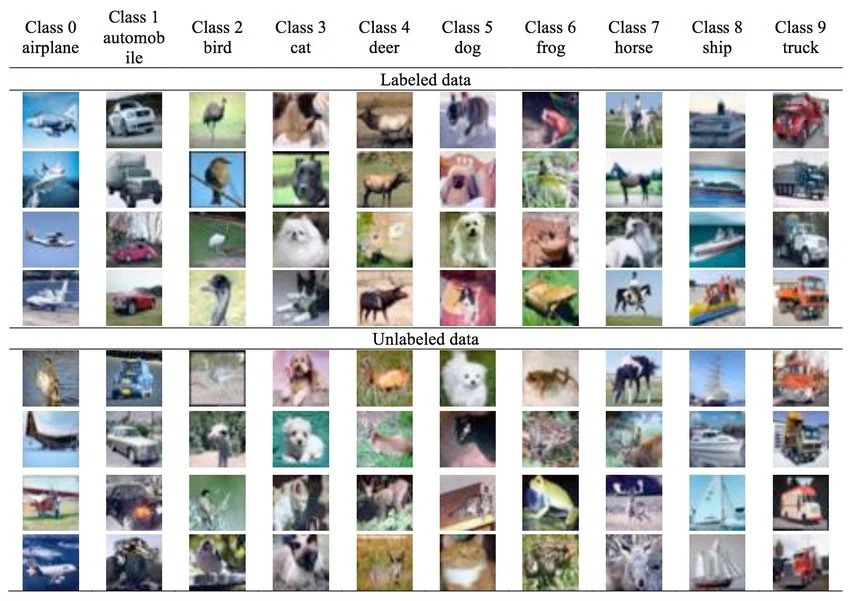

![alt text](RGB-arrays-combined-to-make-image.jpg)

![alt text](1_8zHs6CWVv_ljVQEEZ71fNQ.png)

![alt text](color-channels-RGB.jpg)

In [2]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

c:\Users\Jagdish singh\jupyter311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 1)


In [3]:
# 10 classes
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Label names:", label_names)

Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
print(X_train.shape)  # 3 represent RGB
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


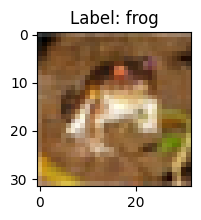

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[0])
plt.title(f"Label: {label_names[y_train[0][0]]}")
plt.show()

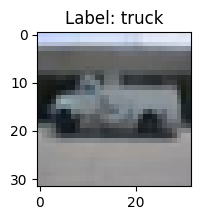

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[110])
plt.title(f"Label: {label_names[y_train[110][0]]}")
plt.show()

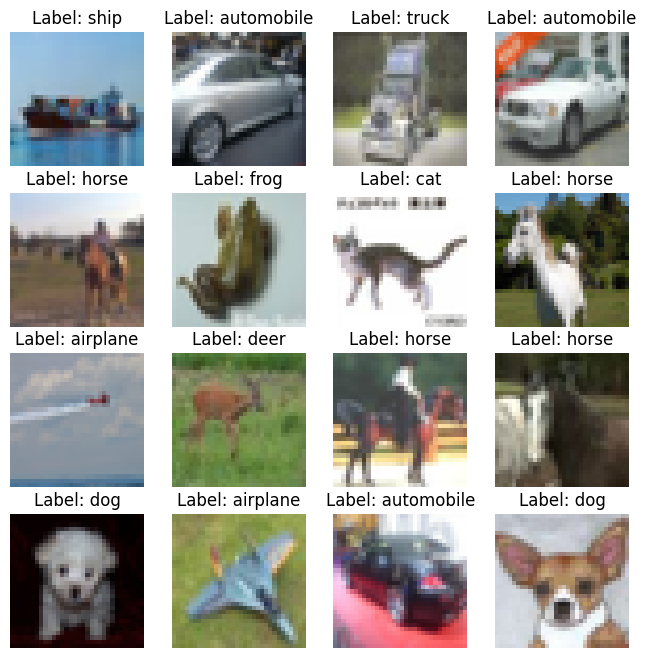

In [ ]:

import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx][0]]}")
    axes[row, col].axis("off")

plt.show()

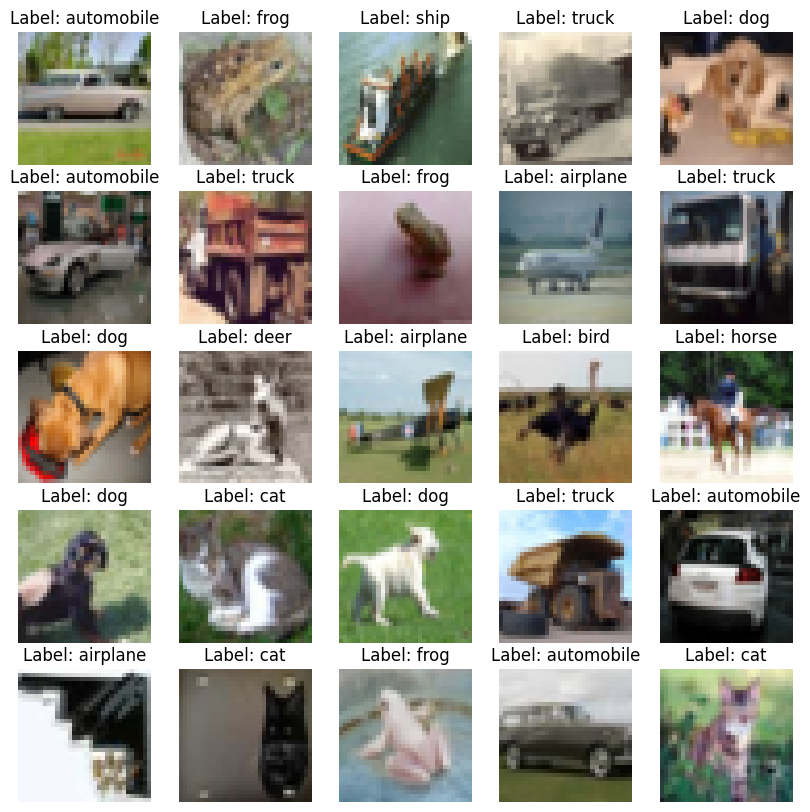

In [31]:
import random
plt.figure(figsize=(10,10))
for i in range(25):
    index = random.randint(0, len(X_train)-1)
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(f"Label: {label_names[y_train[index]]}")
    plt.axis('off')
plt.show()

In [8]:
y_train.shape

(50000, 1)

In [ ]:
# CNN o/p will be 1d

In [ ]:
#  targets are 2D array N x 1 instead of N.
# Therefore, we flatten them.
y_train, y_test = y_train.flatten(), y_test.flatten()
print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [ ]:
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [ ]:
# $[0, 1]$ or $[-1, 1]$
X_train = X_train / 255.0
X_test = X_test / 255.0

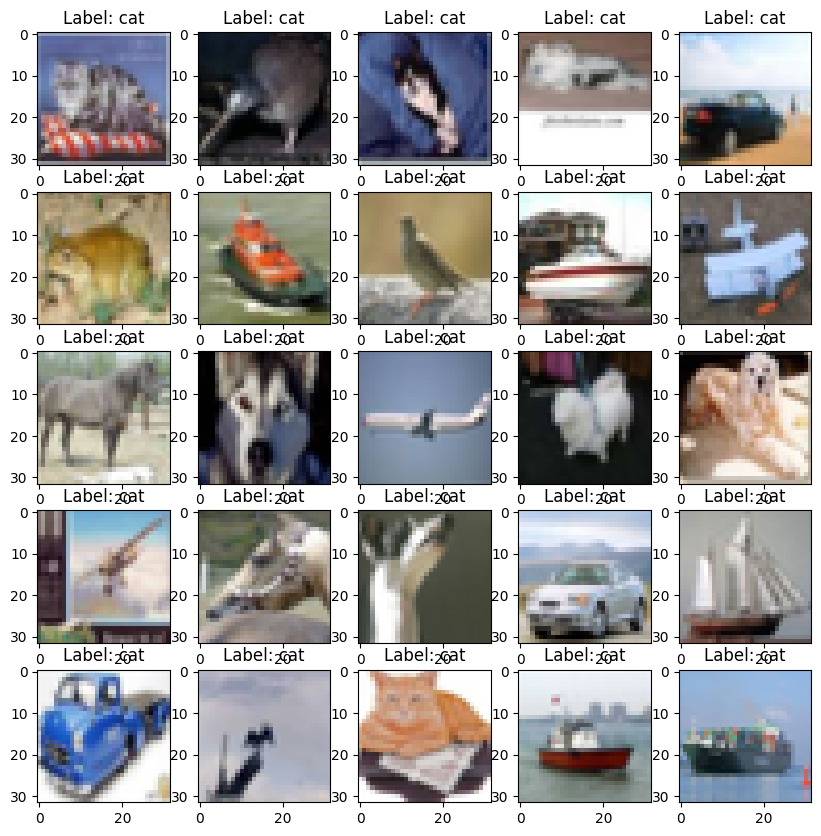

In [38]:
import random
import numpy as np
plt.figure(figsize=(10,10))
for i in range(25):
    indexs=np.random.randint(0,len(X_train))
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[indexs])
    #plt.title(f'label=y_train[indexs]')
    plt.title(f"Label: {label_names[y_train[index]]}")
plt.show()
    

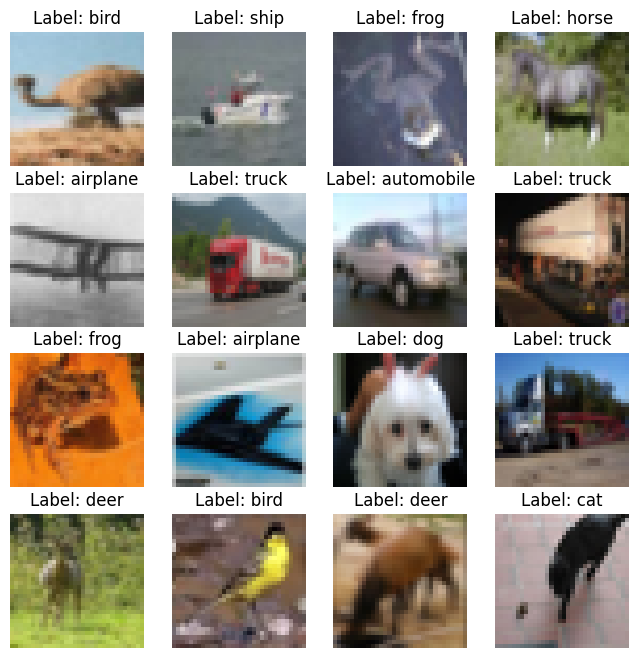

In [12]:
# Lets plot a grid of 4x4 images from the training set along with their labels in the title - randomly select 16 images from the training set
import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx]]}")
    axes[row, col].axis("off")
plt.show()

In [ ]:
# ANN model for image classification

# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# model = Sequential()
# model.add(Input(shape=(32, 32, 3)))
# model.add(Flatten())

# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(10, activation='softmax'))

In [ ]:
'''
Conv2D → extracts image features
MaxPooling2D → reduces image size
Flatten → converts 2D feature maps → 1D vector
Dense → fully connected neural network
Dropout → prevents overfitting
Input → defines input shape
'''

In [ ]:
# earlier we make a simple ANN model only on a colour image dataset

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(32, 32, 3)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))  # 32 filters detect edges & textures
model.add(MaxPooling2D((2, 2)))  # 3×3 kernel scans image  # Pooling reduces size by half
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [43]:
# If you find the model is training slowly or overfitting, try adding Batch Normalization:
# model.add(BatchNormalization())

In [15]:
32*32*3

3072

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,594 (2.52 MB)

 Trainable params: 659,594 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
# Train the model
r = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.2515 - loss: 1.9318 - val_accuracy: 0.4267 - val_loss: 1.5312
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4518 - loss: 1.4779 - val_accuracy: 0.5498 - val_loss: 1.2576
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5444 - loss: 1.2850 - val_accuracy: 0.6167 - val_loss: 1.0630
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.5985 - loss: 1.1657 - val_accuracy: 0.6526 - val_loss: 1.0001
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6342 - loss: 1.0711 - val_accuracy: 0.6643 - val_loss: 0.9816
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.6628 - loss: 1.0012 - val_accuracy: 0.6842 - val_loss: 0.9439
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6834 - loss: 0.9446 - val_accuracy: 0.6950 - val_loss: 0.9071
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6958 - loss: 0.9046 - 

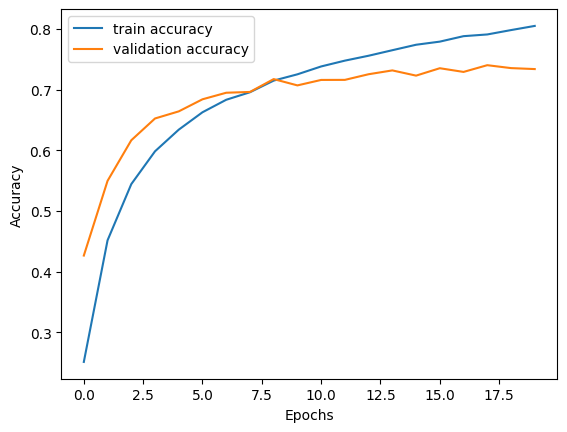

In [19]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

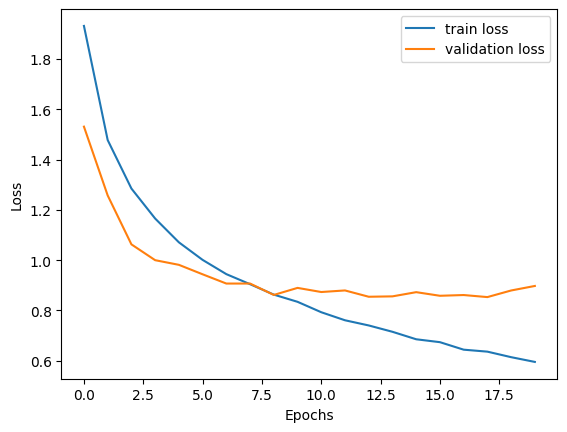

In [20]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
import numpy as np
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [22]:
y_pred.shape

(10000,)

In [23]:
y_test.shape

(10000,)

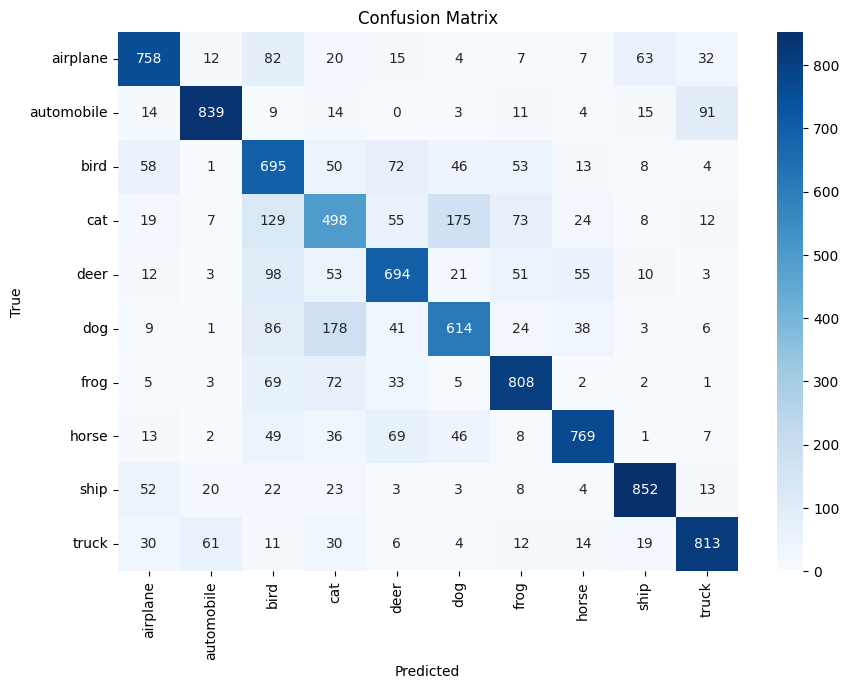

In [24]:
# Lets look at the confusion matrix with True labels on x-axis and Predicted labels on y-axis
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [39]:
cm

array([[758,  12,  82,  20,  15,   4,   7,   7,  63,  32],
       [ 14, 839,   9,  14,   0,   3,  11,   4,  15,  91],
       [ 58,   1, 695,  50,  72,  46,  53,  13,   8,   4],
       [ 19,   7, 129, 498,  55, 175,  73,  24,   8,  12],
       [ 12,   3,  98,  53, 694,  21,  51,  55,  10,   3],
       [  9,   1,  86, 178,  41, 614,  24,  38,   3,   6],
       [  5,   3,  69,  72,  33,   5, 808,   2,   2,   1],
       [ 13,   2,  49,  36,  69,  46,   8, 769,   1,   7],
       [ 52,  20,  22,  23,   3,   3,   8,   4, 852,  13],
       [ 30,  61,  11,  30,   6,   4,  12,  14,  19, 813]])

In [40]:
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_indices

array([  10,   22,   24, ..., 9991, 9995, 9996], shape=(2660,))

In [ ]:

misclassified_indices = np.where(y_test.flatten() != y_pred)[0]
misclassified_indices

array([  10,   22,   24, ..., 9991, 9995, 9996], shape=(2660,))

In [ ]:

print(f'Total misclassified images: {len(misclassified_indices)}')

Total misclassified images: 2660


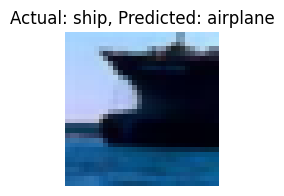

In [ ]:
import random

random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

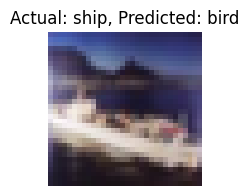

In [42]:
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

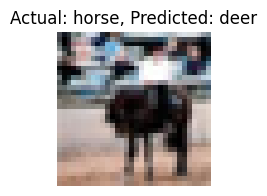

In [ ]:

random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

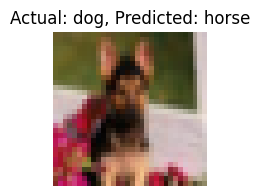

In [ ]:

random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()